# Training an A2C racing agent with GAE

This notebook develops the project-owned synchronous Advantage Actor-Critic agent and its Generalized Advantage Estimation targets. It uses the readable loop in `training/engines/a2c.py`, so rollout collection, bootstrapping, and the separate actor/critic updates remain visible.

The exact equations and episode-boundary rules come from [`docs/LEARNING.md`](../docs/LEARNING.md). The racing MDP and procedural circuits are specified in [`docs/MDP.md`](../docs/MDP.md) and [`docs/TRACK.md`](../docs/TRACK.md).

## Why move from REINFORCE to A2C?

REINFORCE weights each action log-probability with a complete Monte Carlo return. That estimator is direct but noisy, and the actor cannot update until every trajectory ends. A2C adds a critic \(v_w(O_t)\) that predicts the current policy's discounted value. Subtracting this learned state-dependent baseline asks a lower-variance question: was the sampled action better or worse than the policy normally does from this observation?

For each transition, A2C forms the temporal-difference residual

\[
\delta_t = R_{t+1} + \gamma B_t - v_w(O_t),
\]

where \(B_t=0\) after a true terminal state and otherwise is the critic prediction for the next observation. A time-limit truncation therefore retains one bootstrap value: the artificial episode cap is not treated as a physical terminal state.

## Generalized Advantage Estimation and the two losses

A one-step TD residual has lower variance than a Monte Carlo return but can be biased by an inaccurate critic. GAE exposes the trade-off through \(\lambda\):

\[
\widehat{\mathbb A}_t
= \delta_t + \gamma\lambda\widehat{\mathbb A}_{t+1}.
\]

The recursion stops at termination, truncation, environment-column changes, and rollout boundaries. The raw advantage creates the detached critic target \(y_t=\widehat{\mathbb A}_t+v_w(O_t)\); a standardized copy \(\widetilde{\mathbb A}_t\) is used only by the actor. For rollout \(B\),

\[
\mathcal L_{\mathrm{actor}}(\theta)
= -\frac{1}{|B|}\sum_{t\in B}
\log\pi_\theta(A_t\mid O_t)\,
\operatorname{detach}(\widetilde{\mathbb A}_t),
\]

\[
\mathcal L_{\mathrm{critic}}(w)
= \frac{1}{2|B|}\sum_{t\in B}
\left(v_w(O_t)-y_t\right)^2.
\]

A2C can update from fixed-length rollouts that cross episode boundaries, making it more sample-responsive than REINFORCE. Its remaining weakness is that each rollout is used for only one actor/critic update. PPO will reuse the same rollout for several minibatch epochs while constraining how far the actor moves.

## Configuration

The primary stopping rule is `TRAINING_INTERACTION_BUDGET`. Use the same value in all three notebooks for a fair environment-data comparison; the default below matches the frozen Experiment 1 planning budget.

Set `TRAIN_ON_RANDOM_CIRCUITS = True` to derive a fresh procedural circuit from every logical training episode index. The same root and episode index reproduce the same circuit in REINFORCE, A2C, and PPO. Rendering and greedy evaluation stay on one fixed reference circuit.

The initial dashboard shows 20 actions; the final dashboard allows the full 1,000-step environment limit.

In [1]:
import sys
import warnings
from dataclasses import asdict, replace
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT / "src"))
warnings.filterwarnings(
    "ignore",
    message="pkg_resources is deprecated as an API.*",
    category=UserWarning,
    module="pygame.pkgdata",
)

from agents import A2CAgent
from configs import (
    FIXED_CRITIC_CONFIG,
    MEDIUM_ACTOR_CONFIG,
    A2CConfig,
    EnvironmentConfig,
    ExecutionConfig,
    LoggingConfig,
    ObservationNormalizationConfig,
    RenderStyle,
    physical_cpu_count,
    StartStateConfig,
)
from envs.racing import RacingEnv, observation_space_for
from envs.tracks import TrackWithGeometry
from recording import RunCategory
from utils.visualization import (
    plot_algorithm_diagnostics,
    plot_driving_behavior,
    plot_optimization_and_exploration,
    plot_outcomes_and_lap_time,
    plot_progress_and_efficiency,
    plot_task_performance,
    watch_deterministic_rollout,
)
from training import A2CTrainingEngine, TrainingCircuitSchedule
from normalization import RunningObservationNormalizer
from utils.random import (
    RunSeedStreams,
    SeedNamespace,
    SeedStream,
    configure_torch_determinism,
)

# Reproducibility and execution
ROOT_SEED = 0
TRAINING_INTERACTION_BUDGET = 2_000_000
NUM_ENVS = physical_cpu_count()

# Circuit schedule
TRAIN_ON_RANDOM_CIRCUITS = False
SINGLE_CIRCUIT_SEED = 0

# Actor, critic, and A2C
# Rates selected by the pre-experiment calibration in docs/EXPERIMENT.md.
ACTOR_CONFIG = replace(MEDIUM_ACTOR_CONFIG, learning_rate=3e-4)
# The critic's step size lives in its own config, exactly as the
# actor's does, so an agent is configured by two objects and not by
# two objects plus a loose argument.
CRITIC_CONFIG = replace(FIXED_CRITIC_CONFIG, learning_rate=1e-2)
A2C_CONFIG = A2CConfig(
    gae_lambda=0.95,
    transitions_per_rollout=2_048,
)
ENVIRONMENT_CONFIG = EnvironmentConfig()
# Training samples a start pose all around the circuit for state coverage, but
# every greedy evaluation launches from the canonical start line so that the
# reported number always answers the same question and is exactly reproducible.
EVALUATION_CONFIG = replace(
    ENVIRONMENT_CONFIG, start=StartStateConfig(randomized=False)
)
NORMALIZATION_CONFIG = ObservationNormalizationConfig()

# Greedy evaluation and plots
EVALUATION_INTERVAL_INTERACTIONS = 50_000
EVALUATION_EPISODES = 1
MOVING_AVERAGE_WINDOW = 20

# Live rollout dashboard
RENDER_RESET_SEED = 123
VIEWER_MODE = "inline"
# The broadcast style draws the circuit from the driver's seat with a
# telemetry overlay; the minimal style draws the lap as a diagram.
RENDER_STYLE = RenderStyle.BROADCAST
INITIAL_RENDER_STEPS = 20
FINAL_RENDER_STEPS = ENVIRONMENT_CONFIG.simulation.max_episode_steps
LIVE_FRAME_DELAY = 0.01


## Build the reference circuit, random streams, actor, critic, and engine

A2C adds an independent critic-initialization stream. Policy sampling, environment resets, circuit generation, and deterministic evaluation remain isolated. In random-circuit mode, circuit identity is a function of the logical episode number rather than the worker that happens to finish first.

In [2]:
execution_config = ExecutionConfig(environment_workers=NUM_ENVS)
configure_torch_determinism(execution_config)
streams = RunSeedStreams(SeedNamespace.MULTI_CIRCUIT_DEVELOPMENT, ROOT_SEED)
track_streams = RunSeedStreams(
    SeedNamespace.EXPERIMENT_2_TRAINING_TRACK,
    ROOT_SEED,
)

reference_track = TrackWithGeometry.generate(
    SINGLE_CIRCUIT_SEED,
    track_config=ENVIRONMENT_CONFIG.track,
    vehicle_config=ENVIRONMENT_CONFIG.vehicle,
)
tracks = (reference_track,)


def training_track_seed(episode_index):
    generator = track_streams.get_numpy_generator(
        SeedStream.TRACK_GENERATION,
        substream_identity=episode_index,
    )
    return int(generator.integers(0, 2**32, dtype=np.uint32))


observation_dimensions = observation_space_for(
    reference_track, ENVIRONMENT_CONFIG
).shape[0]

agent = A2CAgent(
    observation_dimensions=observation_dimensions,
    actor_config=ACTOR_CONFIG,
    critic_config=CRITIC_CONFIG,
    config=A2C_CONFIG,
    actor_initialization_generator=streams.get_torch_generator(
        SeedStream.ACTOR_INITIALIZATION,
    ),
    critic_initialization_generator=streams.get_torch_generator(
        SeedStream.CRITIC_INITIALIZATION,
    ),
    sampling_generator=tuple(
        streams.get_torch_generator(
            SeedStream.POLICY_ACTION_SAMPLING,
                substream_identity=index,
        )
        for index in range(NUM_ENVS)
    ),
)
normalizer = RunningObservationNormalizer(
    observation_dimensions,
    NORMALIZATION_CONFIG,
)
engine = A2CTrainingEngine(
    agent,
    reference_track,
    ENVIRONMENT_CONFIG,
    normalizer,
    run_category=RunCategory.REDUCED_VALIDATION,
    # The engine now runs the greedy evaluation itself, on the same schedule
    # and from the same canonical start the reported runs use.
    evaluation_environment_factory=lambda: RacingEnv(
        reference_track, config=EVALUATION_CONFIG
    ),
    evaluation_interval=EVALUATION_INTERVAL_INTERACTIONS,
    environment_reset_generators=tuple(
        streams.get_numpy_generator(
            SeedStream.ENVIRONMENT_RESETS,
            substream_identity=index,
        )
        for index in range(NUM_ENVS)
    ),
    track_selection_generators=tuple(
        streams.get_numpy_generator(
            SeedStream.TRAINING_TRACK_SELECTION,
            substream_identity=index,
        )
        for index in range(NUM_ENVS)
    ),
    # Circuits are named by identity and seeded from it, exactly as the
    # reported experiments do, so a notebook run is comparable to one.
    training_circuit_schedule=(
        TrainingCircuitSchedule() if TRAIN_ON_RANDOM_CIRCUITS else None
    ),
    execution_config=execution_config,
    show_progress=True,
    evaluation_seed=int(
        streams.get_numpy_generator(SeedStream.EVALUATION).integers(0, 2**32)
    ),
    root_identity=ROOT_SEED,
    near_saturated_steering_threshold=(
        LoggingConfig().near_saturated_steering_threshold
    ),
)

training_mode = (
    "fresh procedural circuit per episode"
    if TRAIN_ON_RANDOM_CIRCUITS
    else f"fixed circuit seed {SINGLE_CIRCUIT_SEED}"
)
print(f"Training mode: {training_mode}")
print(f"Interaction budget: {TRAINING_INTERACTION_BUDGET:,}")
print(f"Actor parameters: {agent.actor_parameter_count:,}")
print(f"Critic parameters: {agent.critic_parameter_count:,}")

Training mode: fixed circuit seed 0
Interaction budget: 2,000,000
Actor parameters: 4,676
Critic parameters: 4,609


## Policy before training

The short dashboard uses deterministic bounded mean actions and frozen normalization, so it does not consume the stochastic A2C training stream. It combines the circuit view with current progress, return, speed, throttle, steering, and their histories.

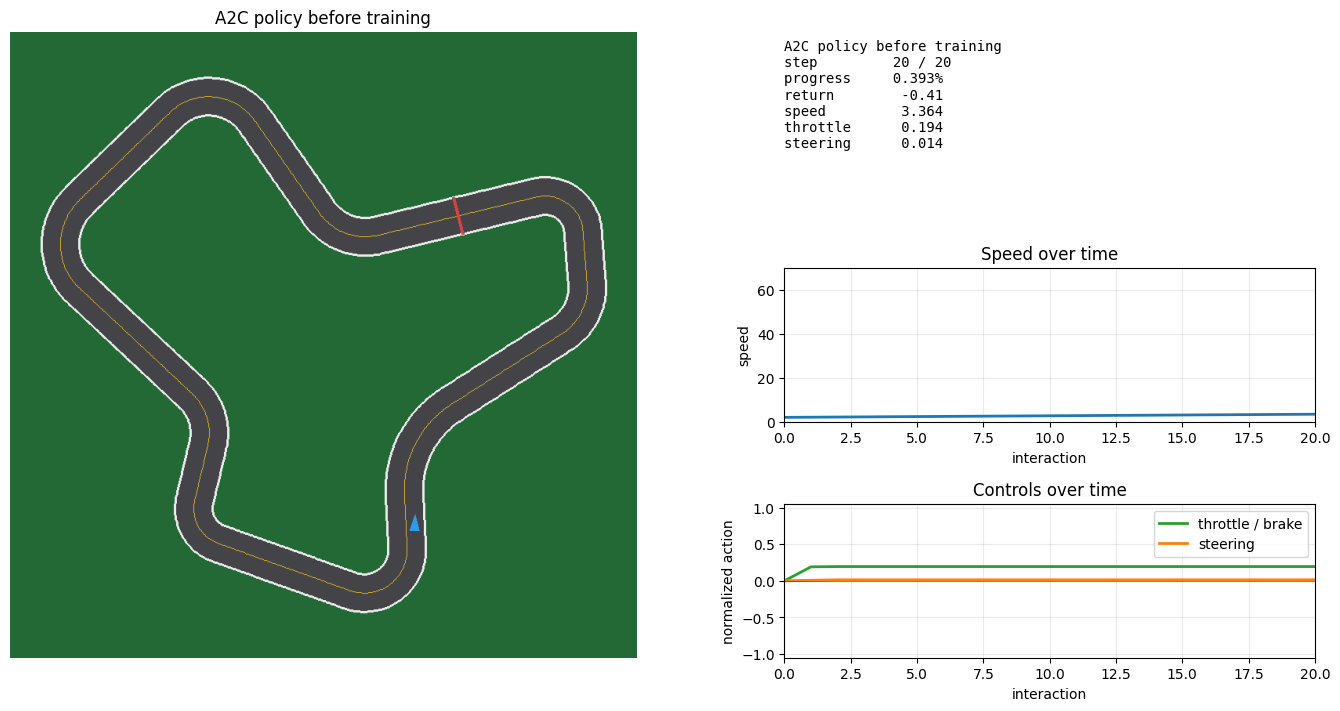

{'interactions': 20,
 'return': -0.4074378357049775,
 'collision': False,
 'lap_completed': False,
 'progress': 0.003925621642950225,
 'final_speed': 3.3638014793395996,
 'final_throttle': 0.19440598785877228,
 'final_steering': 0.013572520576417446}

In [3]:
initial_rollout = watch_deterministic_rollout(
    "A2C policy before training",
    reference_track,
    agent,
    normalizer,
    ENVIRONMENT_CONFIG,
    max_steps=INITIAL_RENDER_STEPS,
    reset_seed=RENDER_RESET_SEED,
    viewer_mode=VIEWER_MODE,
    render_style=RENDER_STYLE,
    frame_delay=LIVE_FRAME_DELAY,
)
initial_rollout

## Scheduled greedy evaluation

Each checkpoint aggregates `EVALUATION_EPISODES` deterministic episodes. Return and progress means are plotted against the actual training-interaction counter, with plus/minus one population standard deviation. On the current deterministic fixed circuit that deviation is normally zero; keeping it explicit makes the presentation correct when evaluation later includes varied starts or circuits.

In [4]:
def evaluation_row(evaluation):
    """
    Summarize one recorded evaluation for the plots below.

    The engine records far more than the curve needs, so the notebook takes
    what it plots from the record rather than the engine reporting a second,
    smaller shape that could drift from it.
    """
    episode = evaluation.record.episode
    return {
        "training_interactions": evaluation.record.training_interactions,
        "return_mean": episode.undiscounted_return,
        "return_standard_deviation": 0.0,
        "maximum_progress_mean": episode.maximum_progress,
        "maximum_progress_standard_deviation": 0.0,
        "lap_time_mean": episode.lap_time,
        "completed_fraction": float(episode.outcome.value == "completed"),
        "outcomes": [episode.outcome.value],
        "completed_training_episodes": None,
    }


def update_row(update):
    """
    Expose one optimizer update in the shape the diagnostic plots read.
    """
    return {
        "training_interactions": update.training_interactions,
        "diagnostics": update.output.diagnostics,
        "optimization_duration": update.optimization_duration,
    }


{'completed_training_episodes': 0,
 'training_interactions': 0,
 'return_mean': -4.470280373831809,
 'return_standard_deviation': 0.0,
 'maximum_progress_mean': 0.07322409022275461,
 'maximum_progress_standard_deviation': 0.0,
 'lap_time_mean': None,
 'completed_fraction': 0.0,
 'outcomes': ['crashed']}

## Train to the common interaction budget

The persistent workers step synchronously into a pooled time-by-environment rollout. GAE recurses only within each worker column. Full 2,048-transition rollouts produce normal A2C updates; the exact budget boundary produces one final shorter rollout rather than overshooting or discarding paid-for interactions.

In [5]:
try:
    state = engine.train(TRAINING_INTERACTION_BUDGET)
    episodes = list(engine.episode_records)
    evaluation_rows = [evaluation_row(row) for row in engine.evaluations]
    update_rows = [update_row(row) for row in engine.updates]
finally:
    engine.close()

print(f"Episodes completed: {len(episodes):,}")
print(f"Training interactions: {state.counters.training_interactions:,}")
print(f"Optimizer updates: {state.counters.optimizer_updates:,}")
print(f"Greedy evaluation checkpoints: {len(evaluation_rows):,}")

Training interactions:   0%|          | 0/2000000 [00:00<?, ?interaction/s]

Episodes completed: 4,471
Training interactions: 2,000,000
Optimizer updates: 977
Greedy evaluation checkpoints: 41


## Prepare the recorded data

A2C now exposes the same episode-level return, progress, length, speed, and throttle summaries as REINFORCE. Update rows add actor and critic losses, weight norms, learned exploration scales, advantage statistics, and critic explained variance.

In [6]:
episode_rows = []
for record in episodes:
    row = asdict(record)
    row["outcome"] = record.outcome.value
    # The record keeps each signal's whole distribution; the curves below plot
    # one number per episode, so the mean is taken here rather than recorded
    # a second time in a shape that could drift from the first.
    row["mean_speed"] = record.speed.mean
    row["mean_throttle"] = record.throttle.mean
    episode_rows.append(row)

print("Last training episode:")
print(episode_rows[-1] if episode_rows else "No episode ended within the budget.")
print("\nLast optimizer update:")
print(update_rows[-1])
print("\nLast greedy evaluation:")
print(evaluation_rows[-1])

Last training episode:
{'episode_index': 4470, 'circuit_identity': '0', 'interactions': 667, 'undiscounted_return': 206.57388509737592, 'outcome': 'completed', 'final_progress': 1.0002885274538, 'maximum_progress': 1.0002885274538, 'mean_speed': 19.338736678528107, 'mean_throttle': 0.2555324341567733, 'mean_throttle_magnitude': 0.4765921554977083, 'lap_time': 26.68}

Last optimizer update:
{'update_index': 976, 'final_episode_index': 4478, 'training_interactions': 2000000, 'transition_count': 1152, 'diagnostics': {'actor_loss': -0.04570287466049194, 'critic_loss': 0.25637543201446533, 'actor_gradient_norm': 0.46159180998802185, 'critic_gradient_norm': 5.1897358894348145, 'actor_weight_norm': 12.231783866882324, 'critic_weight_norm': 30.91838836669922, 'actor_update_norm': 0.004620655905455351, 'critic_update_norm': 0.07559403777122498, 'actor_learning_rate': 0.0003, 'critic_learning_rate': 0.01, 'entropy_proxy': 0.7790447473526001, 'explained_variance': -0.01835179328918457, 'advantage

## Task performance

Training return includes exploration; greedy return evaluates the deterministic bounded mean policy. Keeping them in one category but separate panels avoids conflating behaviour-policy noise with learned deterministic performance.

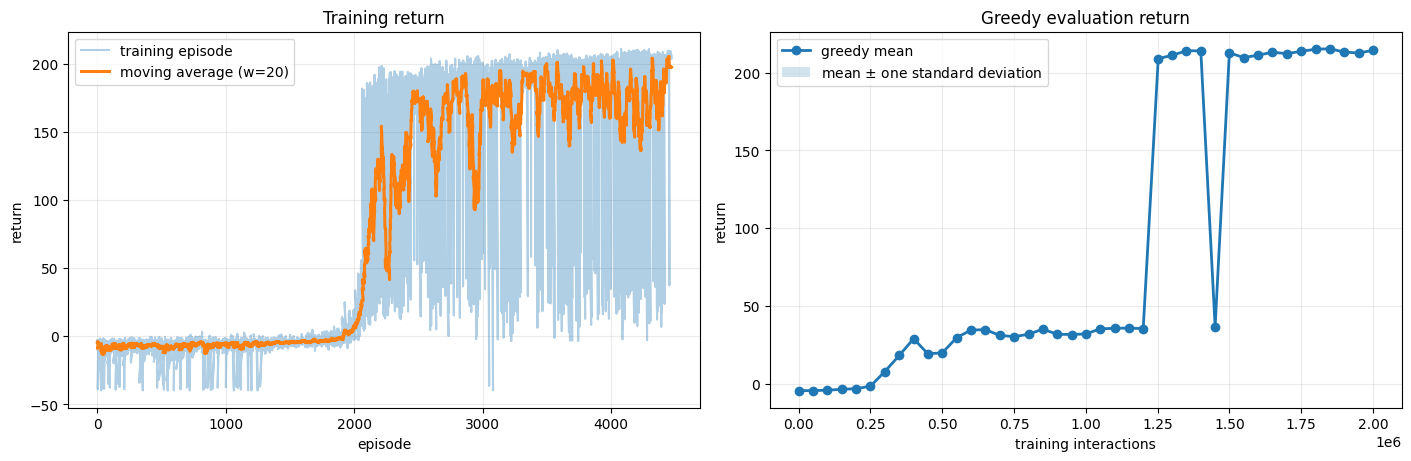

In [7]:
plot_task_performance(
    episode_rows,
    evaluation_rows,
    moving_average_window=MOVING_AVERAGE_WINDOW,
)
plt.show()

## Progress and sample efficiency

Training and greedy maximum progress are shown with their own moving averages. Episode length provides the complementary interaction cost of a training episode.

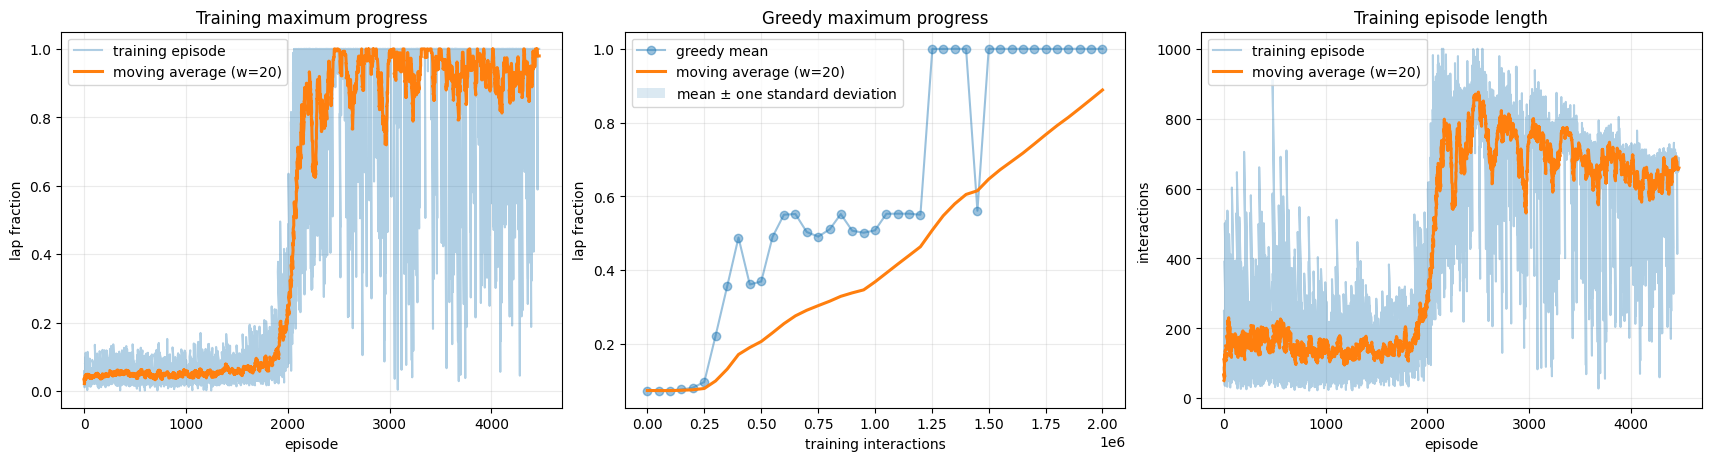

In [8]:
plot_progress_and_efficiency(
    episode_rows,
    evaluation_rows,
    moving_average_window=MOVING_AVERAGE_WINDOW,
)
plt.show()

## Driving behaviour

Mean speed and throttle magnitude expose stalled, timid, or excessively aggressive policies even when shaped return alone is hard to interpret.

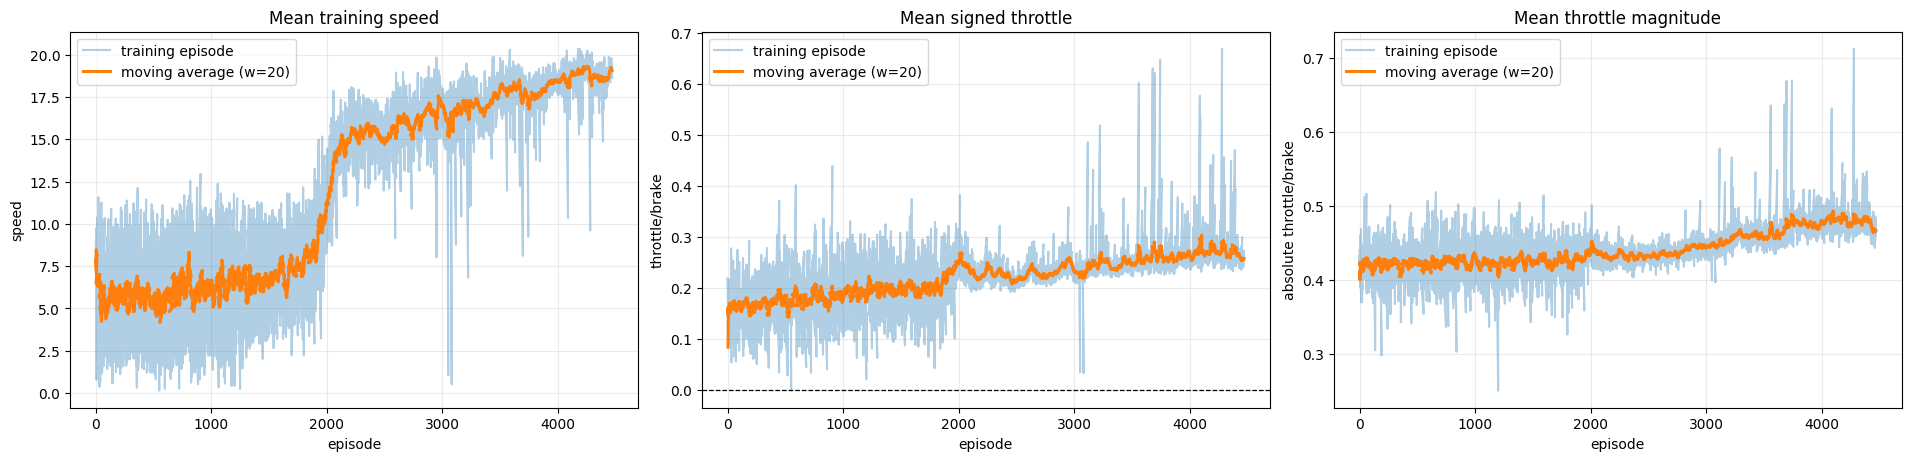

In [9]:
plot_driving_behavior(
    episode_rows,
    moving_average_window=MOVING_AVERAGE_WINDOW,
)
plt.show()

## Outcomes and lap time

Return alone cannot say *why* a policy scores what it scores. The outcome mix separates crashing from idling from lapping, and lap time is the racing objective the return only summarizes.


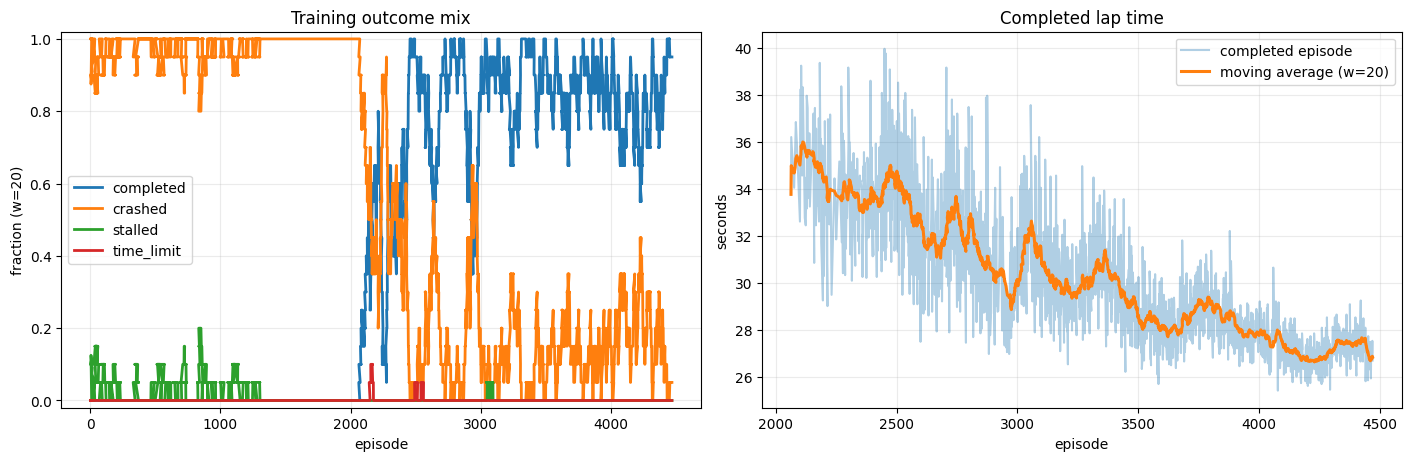

In [10]:
plot_outcomes_and_lap_time(
    episode_rows,
    moving_average_window=MOVING_AVERAGE_WINDOW,
)
plt.show()

## Optimization and learned exploration

Actor and critic losses are separated because their scales and targets differ. Actor and critic weight norms share a panel. The throttle and steering sigma curves are the learned Gaussian exploration trace; no external exploration schedule is imposed.

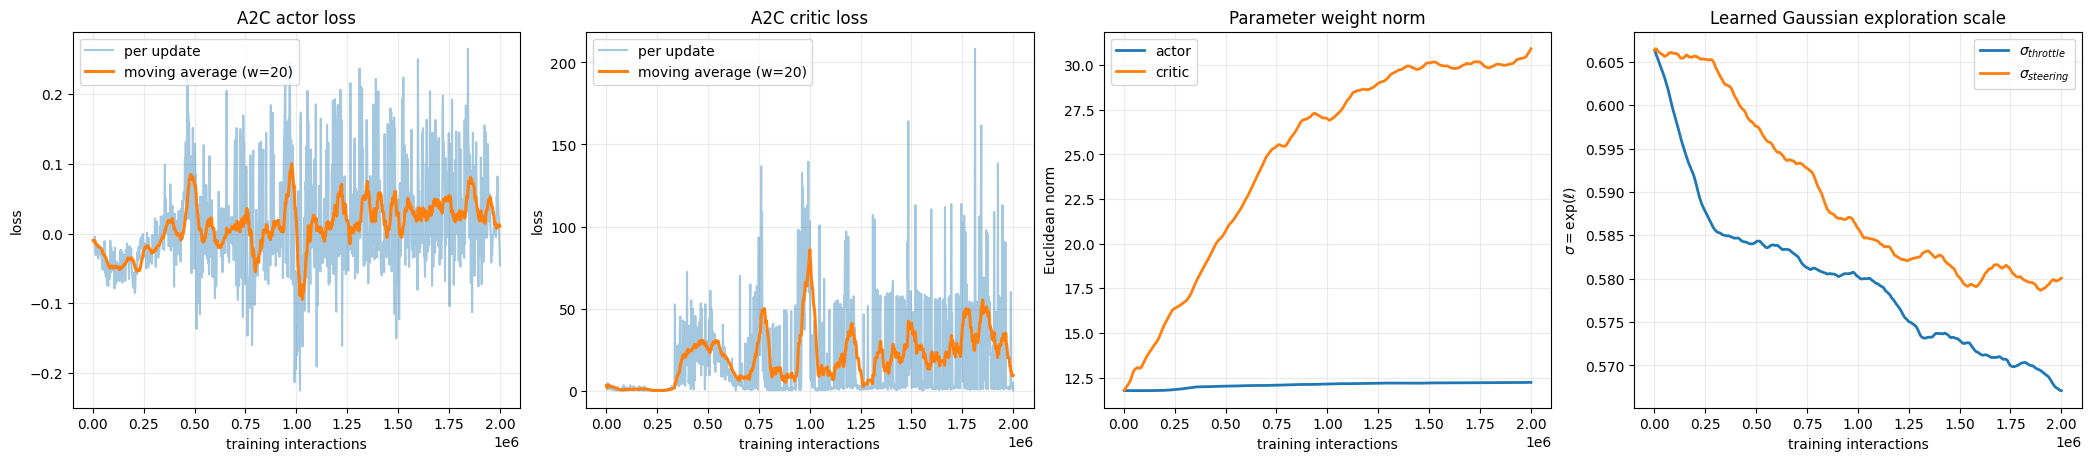

In [11]:
plot_optimization_and_exploration(
    update_rows,
    algorithm_name="A2C",
    moving_average_window=MOVING_AVERAGE_WINDOW,
    include_critic=True,
)
plt.show()

## A2C-specific diagnostics

Raw advantage dispersion shows the scale of the GAE signal before actor standardization. Explained variance indicates how much of the critic-target variation is captured by the value network.

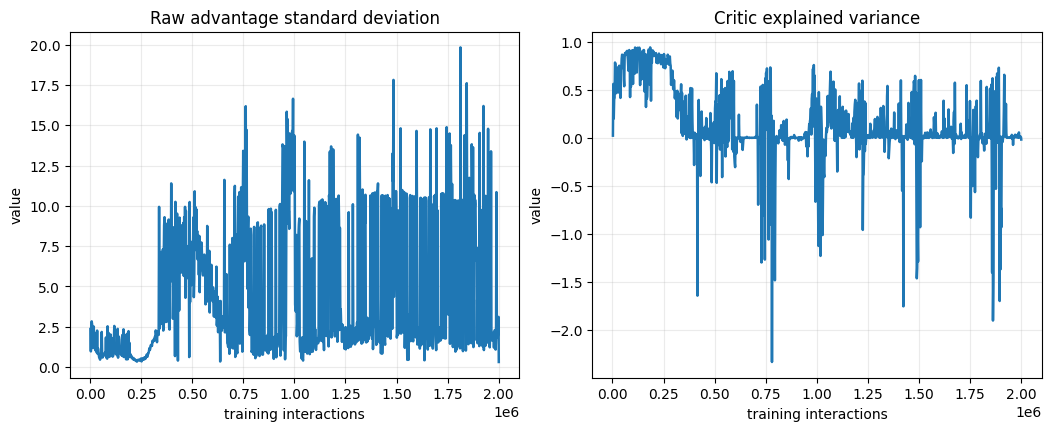

In [12]:
plot_algorithm_diagnostics(
    update_rows,
    algorithm_name="A2C",
)
plt.show()

## Policy after training

The final dashboard reuses the initial circuit, reset seed, deterministic action rule, and frozen normalizer, while allowing all 1,000 actions.

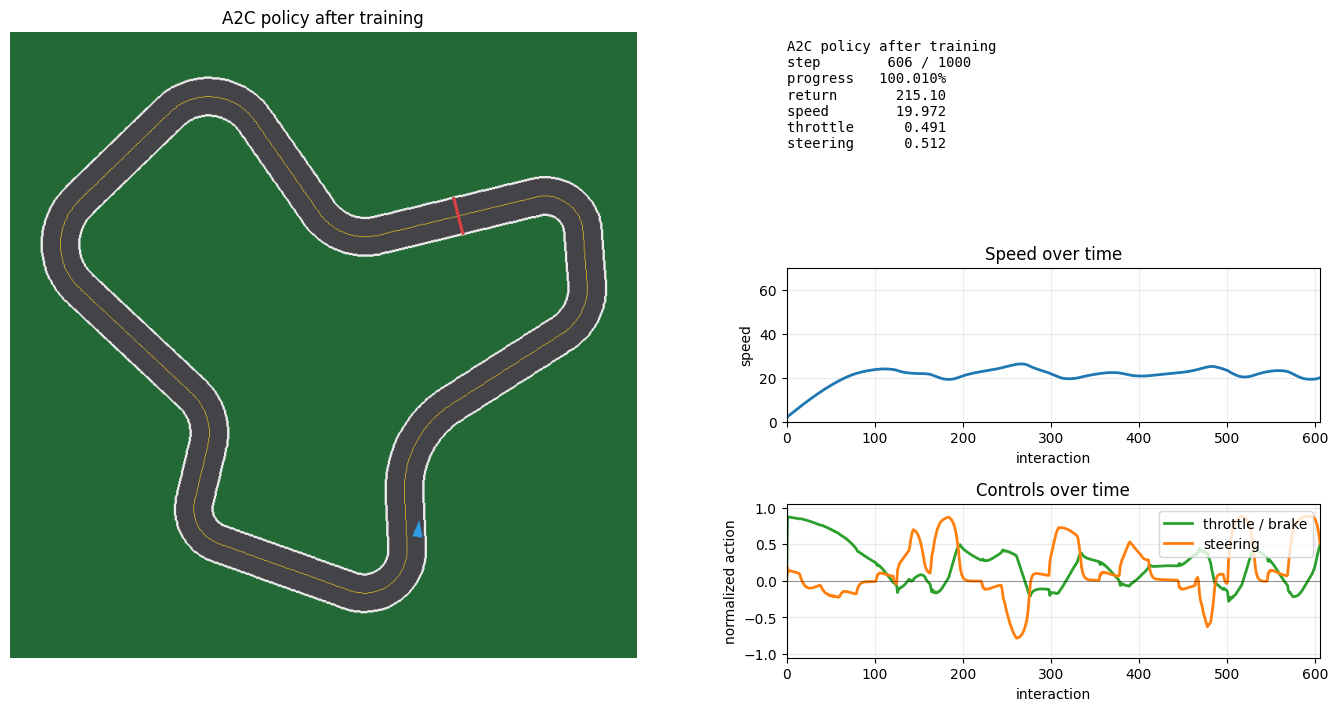

Before training: {'interactions': 20, 'return': -0.4074378357049775, 'collision': False, 'lap_completed': False, 'progress': 0.003925621642950225, 'final_speed': 3.3638014793395996, 'final_throttle': 0.19440598785877228, 'final_steering': 0.013572520576417446}
After training:  {'interactions': 606, 'return': 215.09995407843252, 'collision': False, 'lap_completed': True, 'progress': 1.00009770193831, 'final_speed': 19.97168731689453, 'final_throttle': 0.49074018001556396, 'final_steering': 0.5116150379180908}


: 

In [ ]:
final_rollout = watch_deterministic_rollout(
    "A2C policy after training",
    reference_track,
    agent,
    normalizer,
    ENVIRONMENT_CONFIG,
    max_steps=FINAL_RENDER_STEPS,
    reset_seed=RENDER_RESET_SEED,
    viewer_mode=VIEWER_MODE,
    render_style=RENDER_STYLE,
    frame_delay=LIVE_FRAME_DELAY,
)
print("Before training:", initial_rollout)
print("After training: ", final_rollout)